# HdCam GPS acquisition — end to end

This walks the whole repository once: generating a GPS L1 C/A signal whose answer
we know, acquiring it with the FFT reference correlator, acquiring it with the
1-bit HdCam classifier, and scoring both with the evaluation harness. The last
section swaps the synthetic signal for real output from the vendored gps-sdr-sim
simulator.

Run with `uv run jupyter lab notebooks/example_run.ipynb`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from hdcam_gps.acq_base import AcqConfig
from hdcam_gps.ca_code import ca_code
from hdcam_gps.evaluate import EvalConfig, evaluate
from hdcam_gps.fft_acq import FftAcqClassifier
from hdcam_gps.hdcam_acq import OneBitHdCamClassifier
from hdcam_gps.signal_gen import (
    SatelliteTruth,
    amplitude_for_cn0,
    generate_from_sim,
    generate_synthetic,
)

plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. The C/A codes

Every satellite transmits its own 1023 chip Gold code. Acquisition works at all
because these codes correlate sharply with themselves and barely at all with each
other — the off-peak values are only ever -65, -1 or 63 out of 1023.

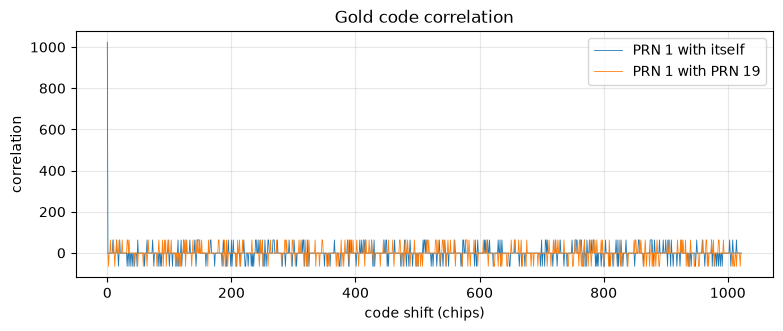

autocorrelation peak : 1023
off-peak values      : [np.int64(-65), np.int64(-1), np.int64(63)]


In [2]:
prn_a, prn_b = ca_code(1).astype(int), ca_code(19).astype(int)
auto = np.array([np.dot(prn_a, np.roll(prn_a, k)) for k in range(1023)])
cross = np.array([np.dot(prn_a, np.roll(prn_b, k)) for k in range(1023)])

fig, ax = plt.subplots()
ax.plot(auto, lw=0.6, label="PRN 1 with itself")
ax.plot(cross, lw=0.6, label="PRN 1 with PRN 19")
ax.set(xlabel="code shift (chips)", ylabel="correlation", title="Gold code correlation")
ax.legend()
plt.show()

print("autocorrelation peak :", auto[0])
print("off-peak values      :", sorted(set(auto[1:]) | set(cross)))

## 2. A signal whose answer we already know

`generate_synthetic` builds a record out of hypotheses we choose, so the label is
the input rather than a measurement. Note how far below the noise the signal
sits — that is not an artefact, it is what GPS actually looks like.

PrnResult(prn=7, doppler_hz=1500.0, code_phase=1234)
PrnResult(prn=19, doppler_hz=-2500.0, code_phase=3000)

signal amplitude 0.0889 against unit noise -> -21 dB below the noise floor


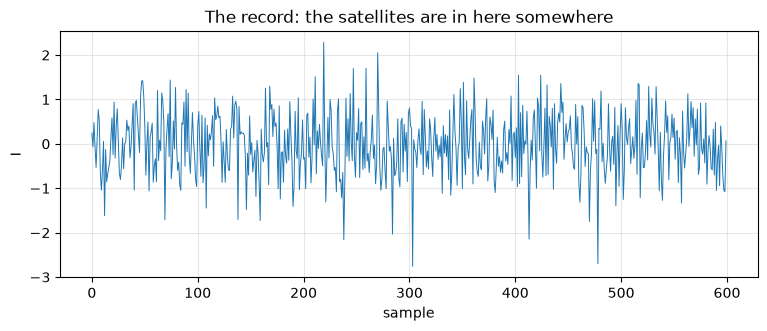

In [3]:
config = AcqConfig(
    fs_hz=4e6, prn_list=tuple(range(1, 33)),
    doppler_min_hz=-5000, doppler_max_hz=5000, doppler_step_hz=500, n_codes=10,
)

scenario = generate_synthetic(config, [
    SatelliteTruth(prn=7, doppler_hz=1500.0, code_phase=1234, cn0_dbhz=45.0),
    SatelliteTruth(prn=19, doppler_hz=-2500.0, code_phase=3000, cn0_dbhz=42.0),
], seed=0)

for want in scenario.expected_results():
    print(want)

amplitude = amplitude_for_cn0(45.0, config.fs_hz)
print(f"\nsignal amplitude {amplitude:.4f} against unit noise "
      f"-> {20 * np.log10(amplitude):.0f} dB below the noise floor")

fig, ax = plt.subplots()
ax.plot(np.real(scenario.samples[:600]), lw=0.7)
ax.set(xlabel="sample", ylabel="I", title="The record: the satellites are in here somewhere")
plt.show()

## 3. The FFT reference classifier

The textbook parallel code phase search: wipe the carrier off at each Doppler
hypothesis, correlate against the local replica for all code phases at once with
an FFT, and accumulate power non-coherently over the code periods.

In [4]:
reference = FftAcqClassifier(config)
results = reference.acquire(scenario.samples)

print("acquired:", *results, sep="\n  ")
print("\nmatches the truth exactly:", results == scenario.expected_results())

acquired:
  PrnResult(prn=7, doppler_hz=1500.0, code_phase=1234)
  PrnResult(prn=19, doppler_hz=-2500.0, code_phase=3000)

matches the truth exactly: True


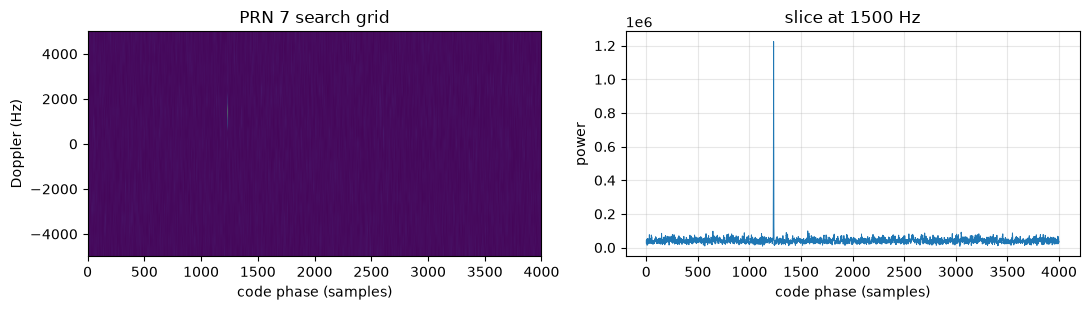

peak at Doppler 1500 Hz, code phase 1234  (truth: 1500 Hz, 1234)


In [5]:
grid = reference.correlate(scenario.samples, prn=7)
peak_bin, peak_phase = np.unravel_index(np.argmax(grid), grid.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].imshow(grid, aspect="auto", origin="lower", cmap="viridis",
               extent=[0, config.samples_per_code,
                       config.doppler_grid_hz[0], config.doppler_grid_hz[-1]])
axes[0].set(xlabel="code phase (samples)", ylabel="Doppler (Hz)",
            title="PRN 7 search grid")
axes[0].grid(False)
axes[1].plot(grid[peak_bin], lw=0.7)
axes[1].set(xlabel="code phase (samples)", ylabel="power",
            title=f"slice at {config.doppler_grid_hz[peak_bin]:.0f} Hz")
plt.tight_layout()
plt.show()

print(f"peak at Doppler {config.doppler_grid_hz[peak_bin]:.0f} Hz, "
      f"code phase {peak_phase}  (truth: 1500 Hz, 1234)")

## 4. The 1-bit HdCam classifier

A different machine entirely. The codebook is one row per (PRN, CFO) hypothesis,
quantized to one bit per component — the carrier phase of every sample rounded to
a quadrant. Acquisition becomes a Hamming distance lookup instead of a
correlation.

Two dimensions the codebook cannot span are handled around the search: code phase
by sliding the query window, and carrier phase by rotating the query through the
four quarter turns a 1-bit sample can express, with the codebook holding the
phases in between.

The CAM search is expensive to simulate, so this uses a smaller configuration.

codebook      : 30 rows x 2046 bits
                = 3 PRN x 5 CFO x 2 stored phases
carrier phases: 8 (4 query quarter turns x 2 codebook offsets)
HD threshold  : 255 of 2046  (chance would be 1023)


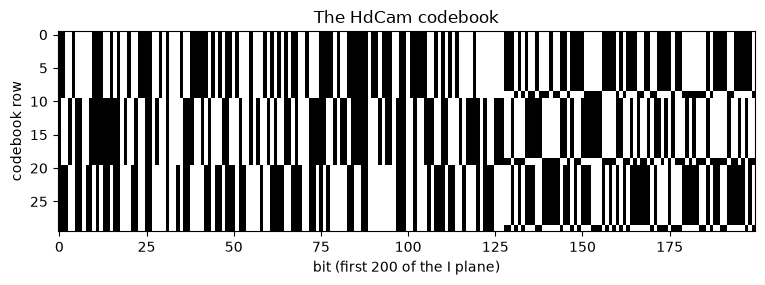

In [6]:
cam_config = AcqConfig(
    fs_hz=1.023e6, prn_list=(1, 7, 19),
    doppler_min_hz=-1000, doppler_max_hz=1000, doppler_step_hz=500, n_codes=2,
)

hdcam = OneBitHdCamClassifier(cam_config)
print(f"codebook      : {hdcam.n_rows} rows x {hdcam.n_columns} bits")
print(f"                = {len(cam_config.prn_list)} PRN x {hdcam.n_doppler_bins} CFO"
      f" x {hdcam.n_codebook_phases} stored phases")
print(f"carrier phases: {hdcam.n_phases} ({4} query quarter turns"
      f" x {hdcam.n_codebook_phases} codebook offsets)")
print(f"HD threshold  : {hdcam.hd_threshold} of {hdcam.n_columns}"
      f"  (chance would be {hdcam.n_columns // 2})")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.imshow(hdcam.cam.grid[:, :200], aspect="auto", cmap="gray", interpolation="nearest")
ax.set(xlabel="bit (first 200 of the I plane)", ylabel="codebook row",
       title="The HdCam codebook")
ax.grid(False)
plt.show()

In [7]:
cam_scenario = generate_synthetic(cam_config, [
    SatelliteTruth(prn=7, doppler_hz=500.0, code_phase=300, cn0_dbhz=75.0),
], seed=1)

cam_results = hdcam.acquire(cam_scenario.samples)
print("truth   :", *cam_scenario.expected_results())
print("acquired:", *cam_results)
print("correct :", cam_scenario.matches(cam_results, code_phase_tolerance=1))

truth   : PrnResult(prn=7, doppler_hz=500.0, code_phase=300)
acquired: PrnResult(prn=7, doppler_hz=500.0, code_phase=300)
correct : True


## 5. Scoring both classifiers

`evaluate` takes any classifier with the `GpsL1AcqClassifier` interface and a
test configuration, sweeps C/N0, and reports quality metrics. Both classifiers
get the same configuration and the same scenarios.

In [8]:
sweep = EvalConfig(
    n_scenarios=5, n_satellites=1,
    cn0_dbhz=(80.0, 70.0, 65.0, 60.0, 50.0, 45.0, 40.0),
)

reports = {}
for name, classifier in [("FFT reference", FftAcqClassifier(cam_config)),
                         ("1-bit HdCam", OneBitHdCamClassifier(cam_config))]:
    reports[name] = evaluate(classifier, sweep)
    print(f"\n{name}\n")
    print(reports[name].table())

FftAcqClassifier:   0%|          | 0/35 [00:00<?, ?scenario/s]


FFT reference

  C/N0  detect   accur  precis   exact  FA/scen  dopp RMSE  phase RMSE   s/scen
-------------------------------------------------------------------------------
    80    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.006
    70    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.004
    65    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.004
    60    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.004
    50    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.004
    45    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.004
    40    0.40    0.40    1.00    0.40     0.00       0.0H       0.00s    0.005


OneBitHdCamClassifier:   0%|          | 0/35 [00:00<?, ?scenario/s]


1-bit HdCam

  C/N0  detect   accur  precis   exact  FA/scen  dopp RMSE  phase RMSE   s/scen
-------------------------------------------------------------------------------
    80    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.423
    70    1.00    1.00    1.00    1.00     0.00       0.0H       0.00s    0.415
    65    0.80    0.80    1.00    0.80     0.00       0.0H       0.00s    0.417
    60    0.00    0.00    0.00    0.00     0.00       0.0H       0.00s    0.423
    50    0.00    0.00    0.00    0.00     0.00       0.0H       0.00s    0.414
    45    0.00    0.00    0.00    0.00     0.00       0.0H       0.00s    0.406
    40    0.00    0.00    0.00    0.00     0.00       0.0H       0.00s    0.445


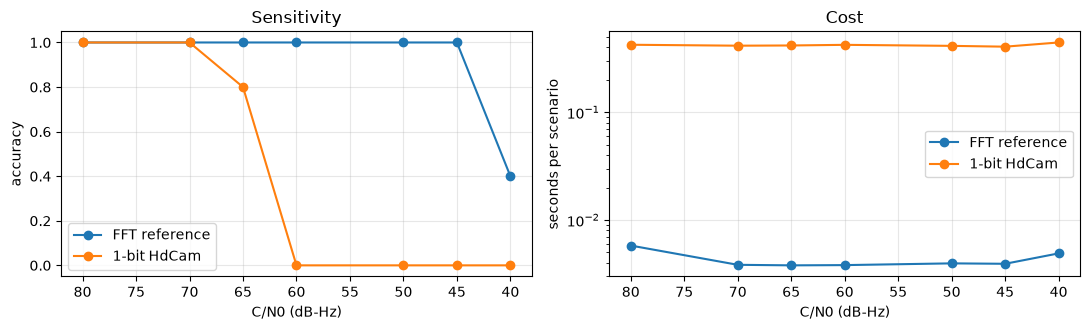

FFT reference   works down to 45.0 dB-Hz
1-bit HdCam     works down to 70.0 dB-Hz


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for name, report in reports.items():
    cn0 = [p.cn0_dbhz for p in report.points]
    axes[0].plot(cn0, [p.accuracy for p in report.points], "o-", label=name)
    axes[1].plot(cn0, [p.seconds_per_scenario for p in report.points], "o-", label=name)

axes[0].set(xlabel="C/N0 (dB-Hz)", ylabel="accuracy", title="Sensitivity", ylim=(-0.05, 1.05))
axes[0].invert_xaxis(); axes[0].legend()
axes[1].set(xlabel="C/N0 (dB-Hz)", ylabel="seconds per scenario", title="Cost", yscale="log")
axes[1].invert_xaxis(); axes[1].legend()
plt.tight_layout()
plt.show()

for name, report in reports.items():
    print(f"{name:15s} works down to {report.sensitivity_cn0_dbhz(0.9)} dB-Hz")

The gap is the headline. The reference correlator keeps working roughly 25 dB
further down than the 1-bit CAM lookup does, which is the price of throwing away
everything but the sign of each sample and replacing a correlation with a
threshold on Hamming distance.

Note also the cost axis: the CAM search is simulated one query at a time in
software, so it is orders of magnitude slower here. In hardware that search is
the parallel operation and the ordering would reverse.

## 6. Real signals from gps-sdr-sim

Everything above used a synthetic signal. `generate_from_sim` drives the vendored
simulator instead: a real constellation from a real broadcast ephemeris, with
real navigation data, ionospheric delay and path loss.

The labels are the simulator's own channel state, exposed by a small patch under
`third_party/patches`, so nothing here is measured from the samples.

In [10]:
sky = generate_from_sim(config, latitude_deg=32.0, longitude_deg=35.0,
                        cn0_dbhz=45.0, seed=0)

print(f"{len(sky.truth)} satellites over 32N 35E\n")
print(f"{'PRN':>4} {'Doppler (Hz)':>13} {'code phase':>11}")
for satellite in sky.truth:
    print(f"{satellite.prn:>4} {satellite.doppler_hz:>13.1f} {satellite.code_phase:>11}")

9 satellites over 32N 35E

 PRN  Doppler (Hz)  code phase
   8        2619.6        2287
  10       -1178.9        1530
  16       -2544.6          87
  18       -2123.1        2613
  21        1988.4        1999
  23       -2724.2        2672
  26       -2890.4        3861
  27         836.5        1226
  32        2574.3        2022


found 9 of 9 satellites
all Dopplers and code phases correct: True


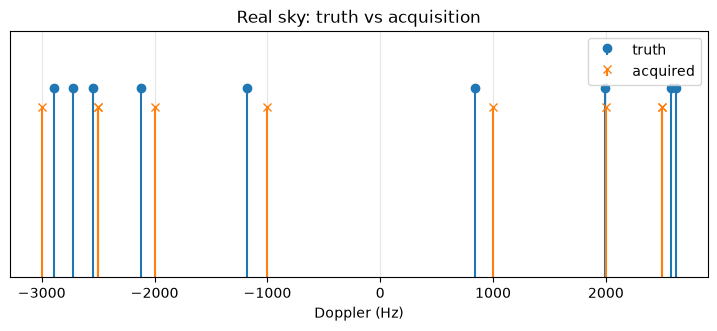

In [11]:
sky_results = reference.acquire(sky.samples)
found = {r.prn for r in sky_results}
truth = {s.prn for s in sky.truth}

print(f"found {len(found & truth)} of {len(truth)} satellites")
print("all Dopplers and code phases correct:",
      sky.matches(sky_results, code_phase_tolerance=1))

fig, ax = plt.subplots()
ax.stem([s.doppler_hz for s in sky.truth], [1] * len(sky.truth),
        linefmt="C0-", markerfmt="C0o", basefmt=" ", label="truth")
ax.stem([r.doppler_hz for r in sky_results], [0.9] * len(sky_results),
        linefmt="C1-", markerfmt="C1x", basefmt=" ", label="acquired")
ax.set(xlabel="Doppler (Hz)", ylabel="", title="Real sky: truth vs acquisition",
       ylim=(0, 1.3), yticks=[])
ax.legend()
plt.show()

In [12]:
sim_sweep = EvalConfig(
    n_scenarios=2, backend="simulator", cn0_dbhz=(48.0, 44.0, 40.0, 36.0),
)
sim_report = evaluate(reference, sim_sweep)
print("FFT reference on real simulator skies (about 9 to 13 satellites each)\n")
print(sim_report.table())

FftAcqClassifier:   0%|          | 0/8 [00:00<?, ?scenario/s]

FFT reference on real simulator skies (about 9 to 13 satellites each)

  C/N0  detect   accur  precis   exact  FA/scen  dopp RMSE  phase RMSE   s/scen
-------------------------------------------------------------------------------
    48    1.00    0.95    1.00    0.50     0.00     165.7H       0.23s    2.165
    44    0.89    0.84    1.00    0.00     0.00     170.6H       0.00s    2.060
    40    0.58    0.53    1.00    0.00     0.00     169.1H       0.00s    2.273
    36    0.21    0.21    1.00    0.00     0.00     168.0H       0.00s    2.062


## What this shows

* The signal generator produces records whose PRN, Doppler and code phase are
  known independently of any acquisition, from either backend.
* The FFT reference recovers them exactly, on synthetic and on simulated skies.
* The 1-bit HdCam classifier recovers them too, but needs roughly 25 dB more
  signal to do it.
* `evaluate` measures that difference on identical scenarios, so the comparison
  is like for like.